In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving blinkit_data.csv to blinkit_data.csv


In [4]:
df=pd.read_csv('blinkit_data.csv')
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4


In [5]:
print("Size of Data:",df.shape)

Size of Data: (8523, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 799.2+ KB


In [7]:
# Field Info
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [8]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


## Data Cleaning


In [9]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [10]:
df['Item Fat Content'] = df['Item Fat Content'].replace(['low fat', 'LF'], 'Low Fat', regex=True)
df['Item Fat Content'] = df['Item Fat Content'].replace(['reg'], 'Regular', regex=True)

In [11]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


## KPI For Business Insights


In [15]:
#Total Sales
total_sales = df['Sales'].sum()
print("Total Sales: $", total_sales)

#Averafe sales
avg_sales=df['Sales'].mean()
print("Average Sales: $", avg_sales)

#No of items sold
no_of_items_sold = df['Sales'].count()
print("Number of Items Sold:", no_of_items_sold)
#Average Ratings
avd_ratings = df['Rating'].mean()
print("Average Ratings:", avd_ratings)

Total Sales: $ 1201681.4808
Average Sales: $ 140.9927819781767
Number of Items Sold: 8523
Average Ratings: 3.9209198638976885


In [16]:
#Total sales by Fat content
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
print(sales_by_fat)

Item Fat Content
Low Fat    776319.6784
Regular    425361.8024
Name: Sales, dtype: float64


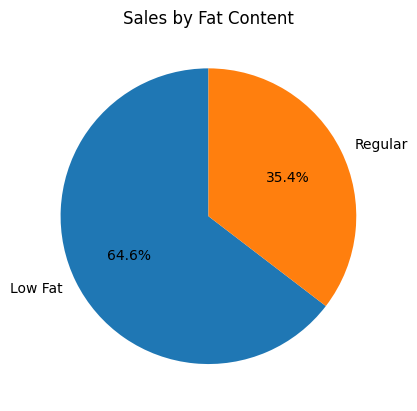

In [21]:
plt.pie(sales_by_fat.values, labels = sales_by_fat.index,
        autopct = '%1.1f%%', startangle = 90)
plt.title('Sales by Fat Content')
plt.show()

In [22]:
# Total Sales By Item Type
sales_by_item_type = df.groupby('Item Type')['Sales'].sum()
print(sales_by_item_type)

Item Type
Baking Goods              81894.7364
Breads                    35379.1198
Breakfast                 15596.6966
Canned                    90706.7270
Dairy                    101276.4596
Frozen Foods             118558.8814
Fruits and Vegetables    178124.0810
Hard Drinks               29334.6766
Health and Hygiene        68025.8388
Household                135976.5254
Meat                      59449.8638
Others                    22451.8916
Seafood                    9077.8700
Snack Foods              175433.9204
Soft Drinks               58514.1650
Starchy Foods             21880.0274
Name: Sales, dtype: float64


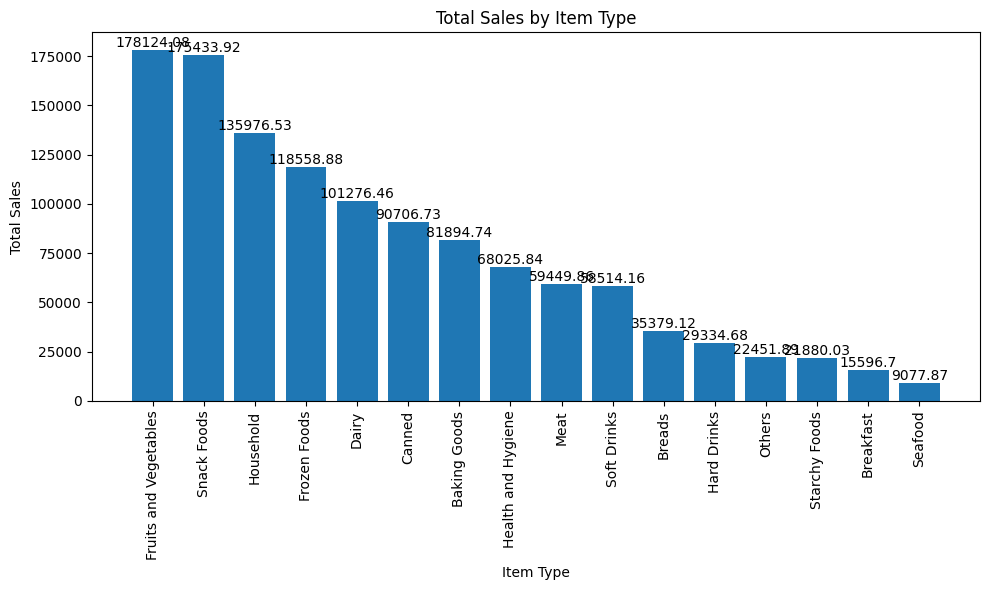

In [28]:
sales_by_item_type = df .groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_item_type.index, sales_by_item_type.values)
plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')
plt.tight_layout()
plt.show()


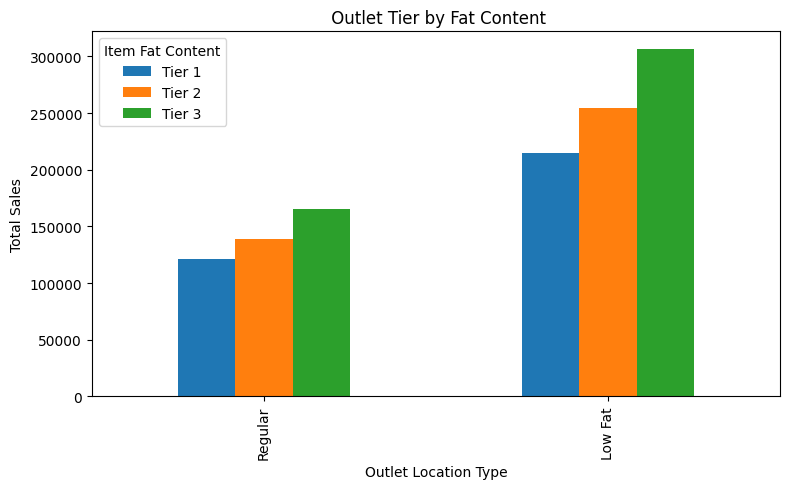

In [40]:
# Fat content by outlet for Total Sales
grouped = df.groupby(['Item Fat Content', 'Outlet Location Type'])['Sales'].sum().unstack()
grouped = grouped.loc[['Regular','Low Fat']]

ax= grouped.plot(kind='bar',figsize=(8,5), title = " Outlet Tier by Fat Content")
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.legend(title="Item Fat Content")
plt.tight_layout()
plt.show()

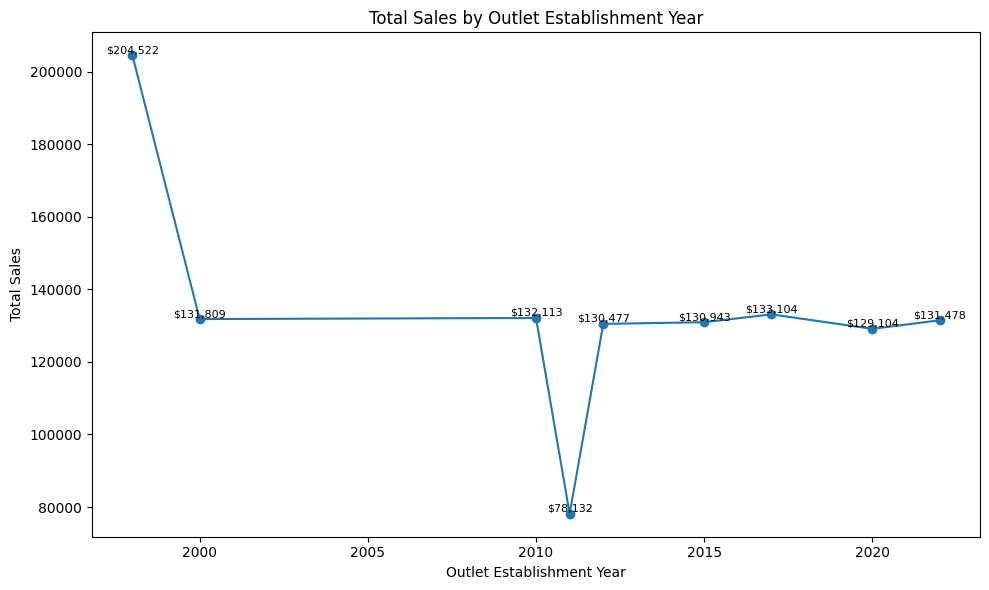

In [42]:
# Total sales by Outlet Establishment
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize=(10,6))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Outlet Establishment Year')

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'${y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

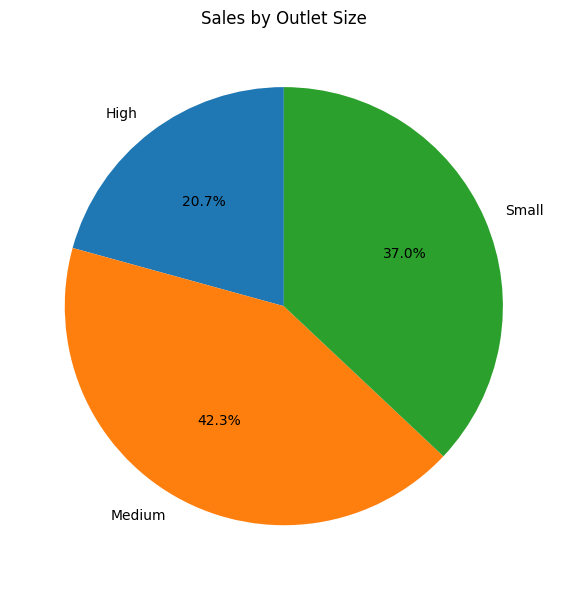

In [44]:
# Sales By Outlet Size
sales_by_outlet_size = df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(10,6))
plt.pie(sales_by_outlet_size.values, labels = sales_by_outlet_size.index,
        autopct = '%1.1f%%', startangle = 90)
plt.title('Sales by Outlet Size')
plt.tight_layout()
plt.show()

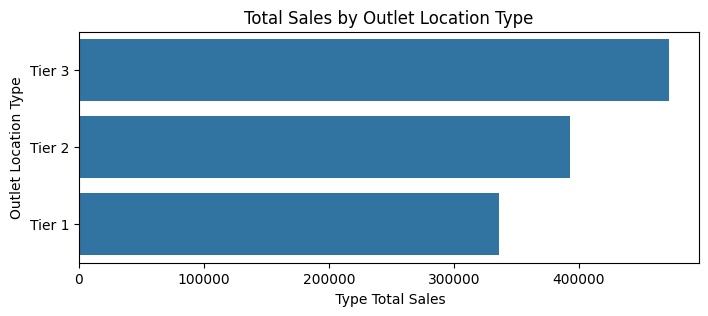

In [46]:
# Sales By Outlet Location
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum( ).reset_index()
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,3))
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)
plt.xlabel(' Type Total Sales')
plt.ylabel('Outlet Location Type')
plt.title('Total Sales by Outlet Location Type')
plt.show()